# 第300章: 潜在空間とは何か

## 📋 この章で学ぶこと

この章を終えると、以下ができるようになります：

- [ ] 潜在空間（Latent Space）の概念を直感的に説明できる
- [ ] 高次元データが低次元に圧縮される仕組みを図解できる
- [ ] マニフォールド仮説を理解し、なぜ潜在空間が存在するか説明できる
- [ ] オートエンコーダ（AE）とVAEの潜在空間の構造的な違いを比較できる
- [ ] 潜在コード（z）を操作して画像がどう変化するかを実験できる

## 🎯 前提知識

この章を学ぶには以下の知識が必要です：

- ✅ Notebook 37-38（VAE理論と実装）
- ✅ Notebook 35-36（PyTorch基礎）
- ✅ 基本的な線形代数（ベクトル、行列）

⏱️ **推定学習時間**: 60-90分
📊 **難易度**: ★★★☆☆（中級）
🎓 **カテゴリ**: 基礎・理論

---

## 🌟 はじめに

### なぜ「潜在空間」を学ぶのか？

画像生成AIが「猫をハンバーガーに変える」「人物の年齢を変える」といった魔法のような変容を行えるのは、
すべて**潜在空間（Latent Space）**という概念のおかげです。

```
               潜在空間を使った画像変容のイメージ

  猫の画像 → [エンコーダ] → 潜在空間のベクトル → [操作] → [デコーダ] → ハンバーガーの画像
  (784次元)                  (わずか2〜512次元)                         (784次元)
```

この章では、潜在空間の基本概念を直感的に理解し、
後続の章（301-316）で学ぶ画像変容技術の土台を築きます。

### 📝 この章の構成

1. **潜在空間の直感** — 次元圧縮のイメージ
2. **マニフォールド仮説** — なぜ低次元に圧縮できるのか
3. **オートエンコーダの潜在空間** — 実際に圧縮してみる
4. **AE vs VAE の潜在空間** — 構造の違いを可視化
5. **潜在コードの操作** — zを動かすと何が起きるか

In [1]:
# ============================================================
# 環境設定
# 必要なライブラリをインポートします
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import warnings

warnings.filterwarnings('ignore')

# 日本語フォント設定
def setup_japanese_font():
    japanese_fonts = [
        'Hiragino Sans', 'Hiragino Maru Gothic Pro',
        'Yu Gothic', 'MS Gothic',
        'Noto Sans CJK JP', 'IPAexGothic',
    ]
    available_fonts = set(f.name for f in fm.fontManager.ttflist)
    for font in japanese_fonts:
        if font in available_fonts:
            plt.rcParams['font.family'] = font
            plt.rcParams['axes.unicode_minus'] = False
            return font
    return None

font_used = setup_japanese_font()

# デバイス設定
device = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if torch.backends.mps.is_available()
                      else 'cpu')

# 再現性
torch.manual_seed(42)
np.random.seed(42)

# グラフスタイル
plt.rcParams['figure.figsize'] = (12, 8)

print(f"日本語フォント: {font_used}")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
print("✅ ライブラリのインポート完了")

日本語フォント: Yu Gothic
PyTorch version: 2.9.1+cpu
Device: cpu
✅ ライブラリのインポート完了


---

## 1. 潜在空間の直感

### 🤔 「潜在」とは何か？

「潜在（latent）」とは、**直接は観測できないが、データの背後に隠れている要因**のことです。

たとえば、手書き数字の画像（28×28=784ピクセル）を考えてみましょう：

```
  観測可能な空間（784次元）         潜在空間（2〜数十次元）
  ┌─────────────────────┐         ┌──────────────┐
  │ ○ ○ ● ● ● ○ ○ ... │         │              │
  │ ○ ● ○ ○ ○ ● ○ ... │   →     │  z = [0.3,   │
  │ ○ ● ○ ○ ○ ● ○ ... │  圧縮    │       -1.2]  │
  │ ○ ○ ● ● ● ○ ○ ... │         │              │
  │ ...       (784個)   │         └──────────────┘
  └─────────────────────┘           たった2個の数字！
```

784個のピクセル値には膨大な冗長性があります。
実際に「意味のある変化」を生み出す要因は、**数字の種類**、**傾き**、**太さ**、**丸み**など、
ごくわずかです。これらの隠れた要因が住む空間が「潜在空間」です。

### 📊 日常の例で考える

| 観測データ | 次元数 | 本質的な要因（潜在変数） | 潜在次元 |
|-----------|--------|----------------------|---------|
| 顔写真 (256×256×3) | 196,608 | 表情、年齢、照明、向き | ~100 |
| 手書き数字 (28×28) | 784 | 数字の種類、太さ、傾き | ~10 |
| 音声波形 (1秒) | 44,100 | 音素、音程、話者 | ~50 |

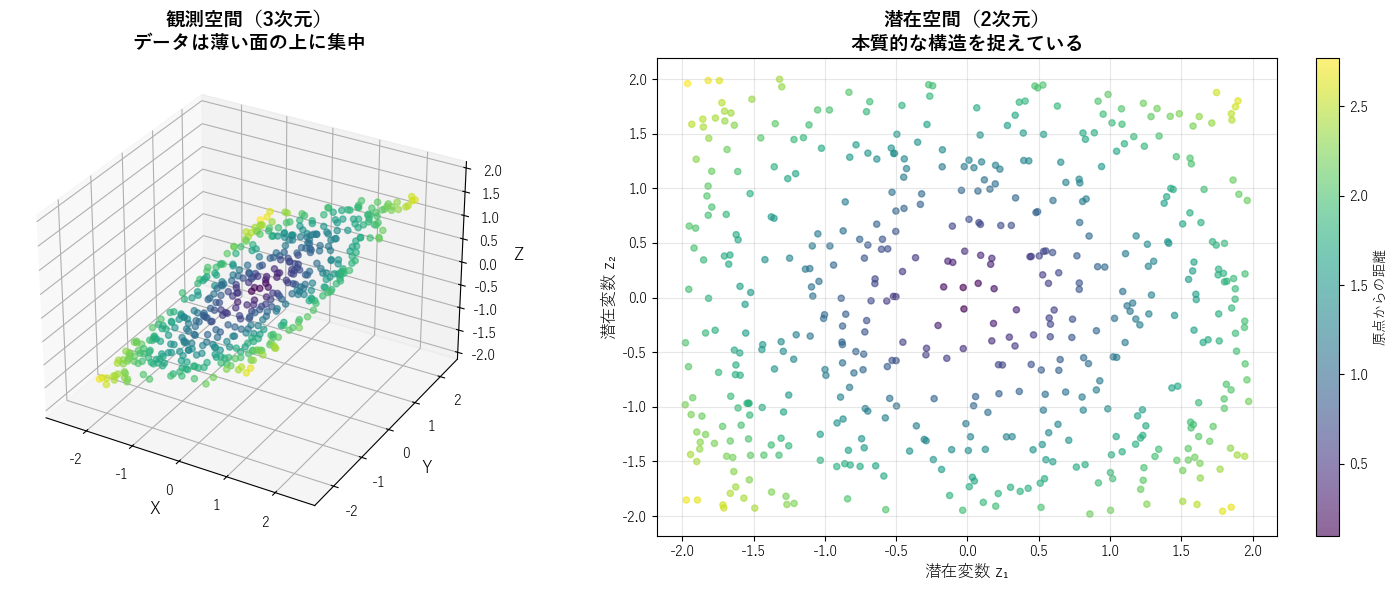

💡 要点: 3次元空間のデータが、実は2次元の構造を持っている
   → これが「潜在空間は低次元」という考え方の基本です


In [2]:
# ============================================================
# 高次元 → 低次元への圧縮を可視化
# 3D空間のデータが実は2D平面上に存在する例
# ============================================================

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(16, 6))

# --- 左: 3D空間に存在するデータ（実は薄い平面上）---
ax1 = fig.add_subplot(121, projection='3d')

# 2Dの潜在変数から3Dデータを生成
n_points = 500
t1 = np.random.uniform(-2, 2, n_points)
t2 = np.random.uniform(-2, 2, n_points)

# 3D空間への写像（薄い曲面上に配置）
x = t1 + 0.3 * t2
y = t2 - 0.2 * t1
z = 0.5 * t1 + 0.5 * t2 + np.random.normal(0, 0.05, n_points)

colors = np.sqrt(t1**2 + t2**2)
ax1.scatter(x, y, z, c=colors, cmap='viridis', alpha=0.6, s=20)
ax1.set_xlabel('X', fontsize=12)
ax1.set_ylabel('Y', fontsize=12)
ax1.set_zlabel('Z', fontsize=12)
ax1.set_title('観測空間（3次元）\nデータは薄い面の上に集中', fontsize=14, fontweight='bold')

# --- 右: 2D潜在空間 ---
ax2 = fig.add_subplot(122)
scatter = ax2.scatter(t1, t2, c=colors, cmap='viridis', alpha=0.6, s=20)
ax2.set_xlabel('潜在変数 z₁', fontsize=12)
ax2.set_ylabel('潜在変数 z₂', fontsize=12)
ax2.set_title('潜在空間（2次元）\n本質的な構造を捉えている', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax2, label='原点からの距離')

plt.tight_layout()
plt.savefig('fig_300_01_dimension_reduction.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 要点: 3次元空間のデータが、実は2次元の構造を持っている")
print("   → これが「潜在空間は低次元」という考え方の基本です")

---

## 2. マニフォールド仮説

### 🤔 なぜ高次元データを低次元に圧縮できるのか？

**マニフォールド仮説（Manifold Hypothesis）**は、機械学習の根幹を成す重要な仮説です：

> **「高次元空間に存在する自然なデータは、実際にはその中の低次元のマニフォールド（多様体）上に集中している」**

### 📊 直感的な理解

スイスロール（Swiss Roll）を例に考えましょう：

```
  3D空間                          展開（2D多様体）
  ┌───────────┐                   ┌──────────────────┐
  │  🌀       │                   │                  │
  │   巻いた  │    展開すると     │  ───────────── │
  │   紙のよう│   ──────→        │  実は平らな紙   │
  │           │                   │                  │
  └───────────┘                   └──────────────────┘
  見た目は3D                      本質は2D
```

画像も同じです。28×28=784次元のピクセル空間の大部分は「意味のない画像」（ランダムノイズ）で、
実際の手書き数字は、その中のごく薄い「膜」の上に存在しています。

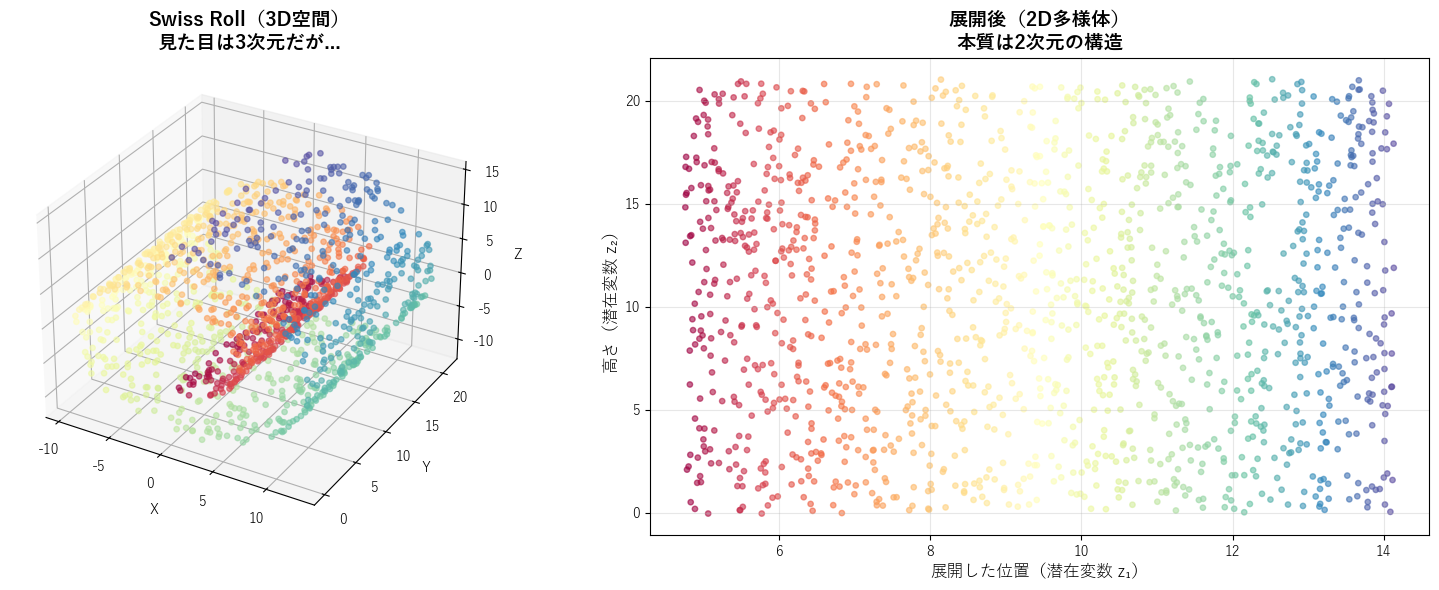

💡 マニフォールド仮説:
   自然なデータ（画像、音声、テキスト）は、高次元空間の中の
   低次元の「膜」の上に集中している

   → だから、エンコーダで低次元に圧縮しても情報を保てる！


In [3]:
# ============================================================
# マニフォールド仮説の可視化
# Swiss Roll: 3D空間の2Dマニフォールド
# ============================================================

from sklearn.datasets import make_swiss_roll

# Swiss Rollデータの生成
n_samples = 1500
X_swiss, color_swiss = make_swiss_roll(n_samples, noise=0.1, random_state=42)

fig = plt.figure(figsize=(16, 6))

# 3D表示
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_swiss[:, 0], X_swiss[:, 1], X_swiss[:, 2],
            c=color_swiss, cmap='Spectral', alpha=0.6, s=15)
ax1.set_title('Swiss Roll（3D空間）\n見た目は3次元だが...', fontsize=14, fontweight='bold')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')

# 展開（真の2D構造）
ax2 = fig.add_subplot(122)
ax2.scatter(color_swiss, X_swiss[:, 1],
            c=color_swiss, cmap='Spectral', alpha=0.6, s=15)
ax2.set_xlabel('展開した位置（潜在変数 z₁）', fontsize=12)
ax2.set_ylabel('高さ（潜在変数 z₂）', fontsize=12)
ax2.set_title('展開後（2D多様体）\n本質は2次元の構造', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_300_02_manifold_hypothesis.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 マニフォールド仮説:")
print("   自然なデータ（画像、音声、テキスト）は、高次元空間の中の")
print("   低次元の「膜」の上に集中している")
print()
print("   → だから、エンコーダで低次元に圧縮しても情報を保てる！")

---

## 3. オートエンコーダで潜在空間を体験する

### 📊 オートエンコーダ（AE）の仕組み

```
  入力画像 x          潜在コード z         再構成画像 x̂
  (784次元)           (2次元)              (784次元)

  ┌─────┐    圧縮     ┌───┐     復元      ┌─────┐
  │     │ ─────────→ │ z │ ─────────→   │     │
  │  3  │  エンコーダ  │   │  デコーダ     │  3  │
  │     │   E(x)     └───┘   D(z)       │     │
  └─────┘                                └─────┘
```

**ボトルネック構造**がポイントです：
- 784次元 → 128 → 64 → **2次元** → 64 → 128 → 784次元
- 2次元のボトルネックを通過するとき、**本当に重要な情報だけが残る**

MNISTデータで実際にやってみましょう！

In [4]:
# ============================================================
# MNISTデータの準備
# ============================================================

# データのダウンロードと前処理
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

print(f"✅ MNISTデータセット準備完了")
print(f"   訓練データ: {len(train_dataset)}枚")
print(f"   テストデータ: {len(test_dataset)}枚")
print(f"   画像サイズ: 28×28 = 784ピクセル")

100%|██████████| 9.91M/9.91M [03:20<00:00, 49.5kB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 156kB/s]
100%|██████████| 1.65M/1.65M [00:09<00:00, 175kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.26MB/s]

✅ MNISTデータセット準備完了
   訓練データ: 60000枚
   テストデータ: 10000枚
   画像サイズ: 28×28 = 784ピクセル


In [5]:
# ============================================================
# シンプルなオートエンコーダ（AE）の定義
# 潜在空間を2次元にして可視化できるようにする
# ============================================================

class SimpleAutoencoder(nn.Module):
    """シンプルなオートエンコーダ（潜在次元=2）"""

    def __init__(self, latent_dim=2):
        super().__init__()

        # エンコーダ: 784 → 128 → 64 → 2
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim),
        )

        # デコーダ: 2 → 64 → 128 → 784
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid(),  # ピクセル値を[0,1]に
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)
        x_recon = self.decode(z)
        return x_recon, z

model_ae = SimpleAutoencoder(latent_dim=2).to(device)

# パラメータ数の確認
total_params = sum(p.numel() for p in model_ae.parameters())
print(f"✅ オートエンコーダ構築完了")
print(f"   潜在次元: 2")
print(f"   総パラメータ数: {total_params:,}")
print()
print(model_ae)

✅ オートエンコーダ構築完了
   潜在次元: 2
   総パラメータ数: 218,514

SimpleAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


In [6]:
# ============================================================
# AEの学習
# ============================================================

optimizer_ae = optim.Adam(model_ae.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

n_epochs = 15
losses_ae = []

print("AEの学習を開始します...")
print("=" * 50)

for epoch in range(n_epochs):
    model_ae.train()
    epoch_loss = 0
    for batch_x, _ in train_loader:
        batch_x = batch_x.view(-1, 784).to(device)

        x_recon, z = model_ae(batch_x)
        loss = loss_fn(x_recon, batch_x)

        optimizer_ae.zero_grad()
        loss.backward()
        optimizer_ae.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    losses_ae.append(avg_loss)

    if (epoch + 1) % 3 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:2d}/{n_epochs} | Loss: {avg_loss:.6f}")

print("=" * 50)
print("✅ 学習完了！")

AEの学習を開始します...
  Epoch  1/15 | Loss: 0.074268
  Epoch  3/15 | Loss: 0.050671
  Epoch  6/15 | Loss: 0.045791
  Epoch  9/15 | Loss: 0.043042
  Epoch 12/15 | Loss: 0.041750
  Epoch 15/15 | Loss: 0.040830
✅ 学習完了！


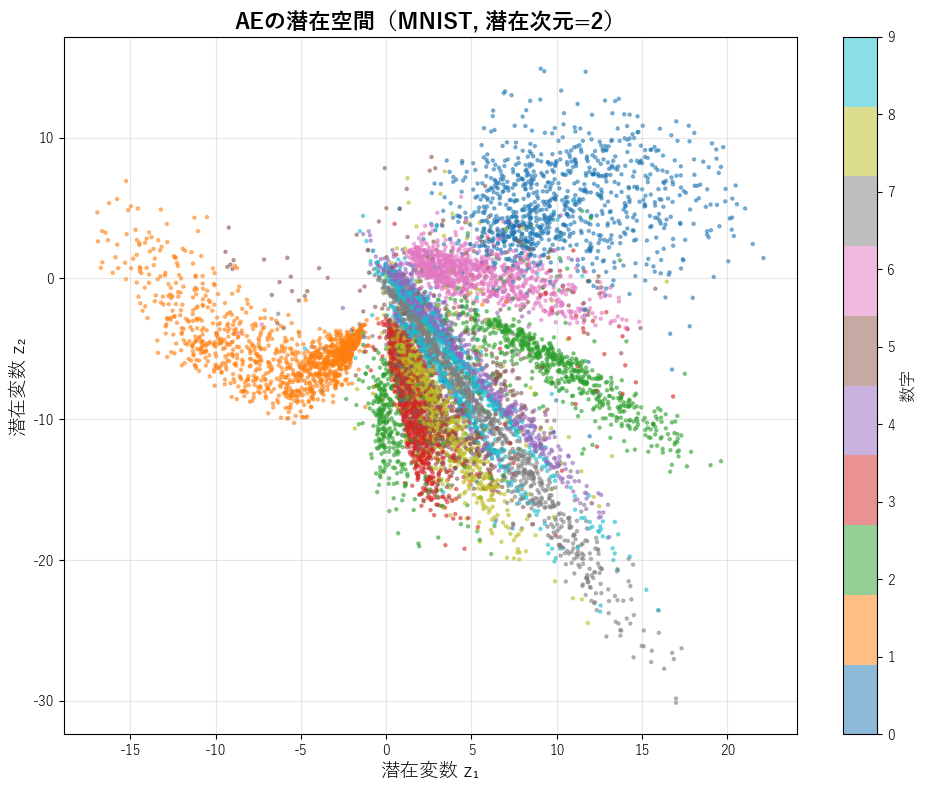

💡 観察ポイント:
   - 同じ数字のデータが近くに集まっている → 潜在空間が「意味」を学習
   - ただし、クラスタ間に隙間や重なりがある → AEの限界


In [7]:
# ============================================================
# AEの潜在空間を可視化
# テストデータをエンコードして2D空間にプロット
# ============================================================

model_ae.eval()
all_z = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.view(-1, 784).to(device)
        z = model_ae.encode(batch_x)
        all_z.append(z.cpu().numpy())
        all_labels.append(batch_y.numpy())

all_z = np.concatenate(all_z, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# 可視化
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
scatter = ax.scatter(all_z[:, 0], all_z[:, 1],
                     c=all_labels, cmap='tab10', alpha=0.5, s=5)
ax.set_xlabel('潜在変数 z₁', fontsize=14)
ax.set_ylabel('潜在変数 z₂', fontsize=14)
ax.set_title('AEの潜在空間（MNIST, 潜在次元=2）', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)

# カラーバー（数字のラベル）
cbar = plt.colorbar(scatter, ax=ax, ticks=range(10))
cbar.set_label('数字', fontsize=12)
cbar.ax.set_yticklabels([str(i) for i in range(10)])

plt.tight_layout()
plt.savefig('fig_300_03_ae_latent_space.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 観察ポイント:")
print("   - 同じ数字のデータが近くに集まっている → 潜在空間が「意味」を学習")
print("   - ただし、クラスタ間に隙間や重なりがある → AEの限界")

---

## 4. AE vs VAE — 潜在空間の構造の違い

### 🤔 AEの潜在空間の問題点

AEは再構成誤差だけを最小化するので、潜在空間の**構造**について何も保証しません：

| 特性 | AE | VAE |
|------|-----|------|
| 学習目標 | 再構成誤差の最小化 | ELBO（再構成 + KL正則化） |
| 潜在空間の構造 | 不規則、隙間だらけ | 連続的、正規分布に近い |
| 補間の品質 | 途中で崩れやすい | スムーズな変化 |
| 画像生成 | ❌ 困難 | ✅ 可能 |

VAEは**KLダイバージェンス項**によって、潜在空間を標準正規分布 N(0, I) に近づけます。
この正則化のおかげで、**潜在空間のどの点からでも意味のある画像を生成**できます。

In [8]:
# ============================================================
# シンプルなVAEの定義
# AEとの比較のため
# ============================================================

class SimpleVAE(nn.Module):
    """シンプルなVAE（潜在次元=2）"""

    def __init__(self, latent_dim=2):
        super().__init__()
        self.latent_dim = latent_dim

        # エンコーダ: 784 → 128 → 64 → (μ, log σ²)
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)

        # デコーダ: 2 → 64 → 128 → 784
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

model_vae = SimpleVAE(latent_dim=2).to(device)
print(f"✅ VAE構築完了（潜在次元=2）")

✅ VAE構築完了（潜在次元=2）


In [9]:
# ============================================================
# VAEの学習
# ============================================================

optimizer_vae = optim.Adam(model_vae.parameters(), lr=1e-3)

def vae_loss(x_recon, x, mu, logvar):
    recon_loss = nn.functional.binary_cross_entropy(x_recon, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss

n_epochs = 15
losses_vae = []

print("VAEの学習を開始します...")
print("=" * 50)

for epoch in range(n_epochs):
    model_vae.train()
    epoch_loss = 0
    for batch_x, _ in train_loader:
        batch_x = batch_x.view(-1, 784).to(device)
        x_recon, mu, logvar = model_vae(batch_x)
        loss = vae_loss(x_recon, batch_x, mu, logvar)
        optimizer_vae.zero_grad()
        loss.backward()
        optimizer_vae.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_dataset)
    losses_vae.append(avg_loss)

    if (epoch + 1) % 3 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:2d}/{n_epochs} | Loss: {avg_loss:.2f}")

print("=" * 50)
print("✅ 学習完了！")

VAEの学習を開始します...
  Epoch  1/15 | Loss: 220.64
  Epoch  3/15 | Loss: 168.72
  Epoch  6/15 | Loss: 160.91
  Epoch  9/15 | Loss: 155.82
  Epoch 12/15 | Loss: 153.00
  Epoch 15/15 | Loss: 150.86
✅ 学習完了！


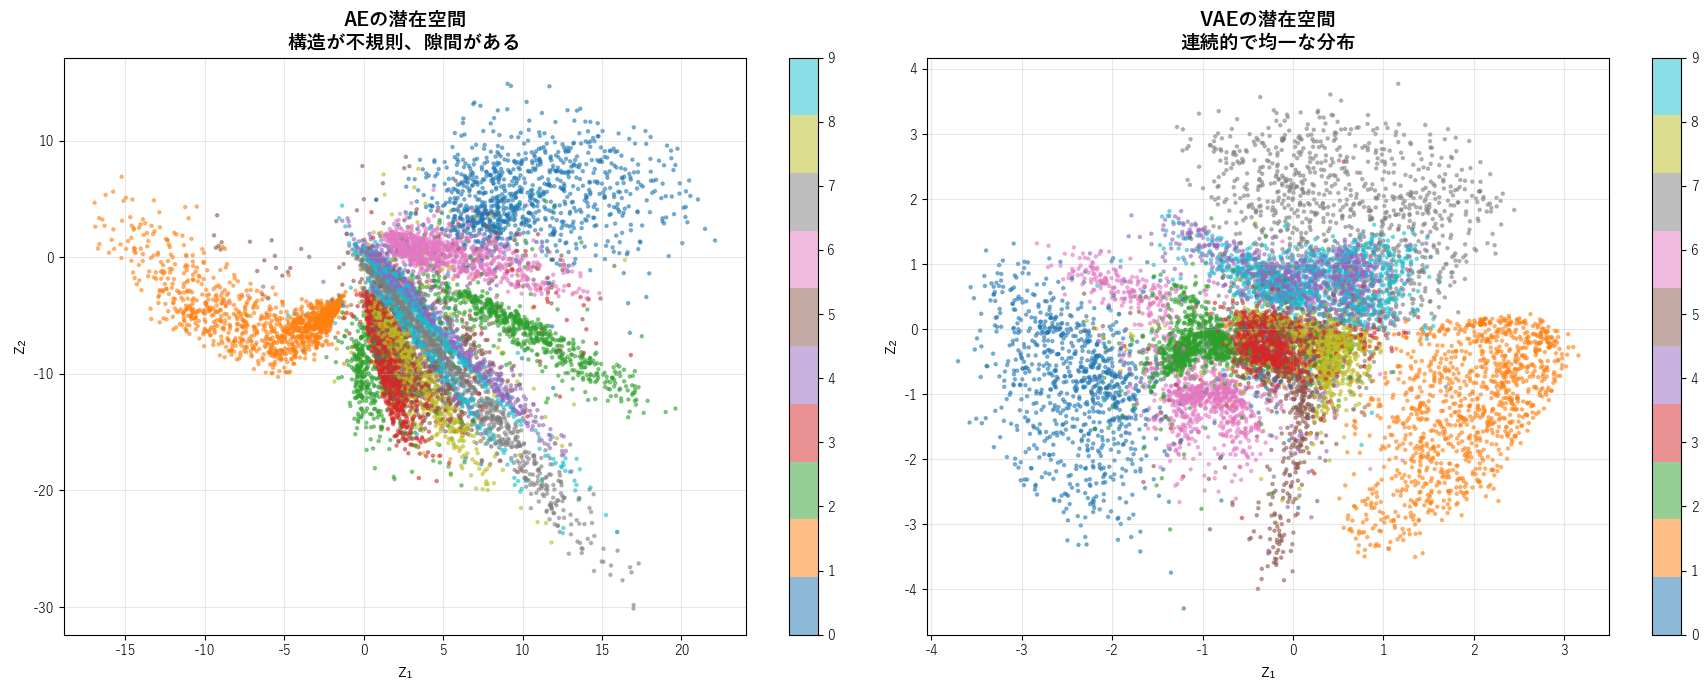

💡 AE vs VAE の違い:
   AE:  クラスタがバラバラで隙間が多い → 隙間の点をデコードすると崩れた画像に
   VAE: KL正則化により連続的で均一 → どの点からも意味のある画像を生成可能


In [10]:
# ============================================================
# AE vs VAE：潜在空間の比較
# ============================================================

model_vae.eval()
all_z_vae = []
all_labels_vae = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.view(-1, 784).to(device)
        mu, _ = model_vae.encode(batch_x)
        all_z_vae.append(mu.cpu().numpy())
        all_labels_vae.append(batch_y.numpy())

all_z_vae = np.concatenate(all_z_vae, axis=0)
all_labels_vae = np.concatenate(all_labels_vae, axis=0)

# 並列比較
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# AE
scatter1 = axes[0].scatter(all_z[:, 0], all_z[:, 1],
                           c=all_labels, cmap='tab10', alpha=0.5, s=5)
axes[0].set_xlabel('z₁', fontsize=14)
axes[0].set_ylabel('z₂', fontsize=14)
axes[0].set_title('AEの潜在空間\n構造が不規則、隙間がある', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], ticks=range(10))

# VAE
scatter2 = axes[1].scatter(all_z_vae[:, 0], all_z_vae[:, 1],
                           c=all_labels_vae, cmap='tab10', alpha=0.5, s=5)
axes[1].set_xlabel('z₁', fontsize=14)
axes[1].set_ylabel('z₂', fontsize=14)
axes[1].set_title('VAEの潜在空間\n連続的で均一な分布', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], ticks=range(10))

plt.tight_layout()
plt.savefig('fig_300_04_ae_vs_vae_latent.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 AE vs VAE の違い:")
print("   AE:  クラスタがバラバラで隙間が多い → 隙間の点をデコードすると崩れた画像に")
print("   VAE: KL正則化により連続的で均一 → どの点からも意味のある画像を生成可能")

---

## 5. 潜在コードの操作 — zを動かすと何が起きるか

### ここが画像変容の出発点！

潜在空間が**連続的で構造化**されていれば、潜在コード z を少しずつ動かすことで、
生成される画像も**滑らかに変化**します。

```
  z₁方向に動かすと...         z₂方向に動かすと...
  ┌───┬───┬───┬───┬───┐      ┌───┬───┬───┬───┬───┐
  │ 3 │ 3 │ 8 │ 8 │ 0 │      │ 1 │ 1 │ 7 │ 7 │ 7 │
  └───┴───┴───┴───┴───┘      └───┴───┴───┴───┴───┘
  数字の「種類」が変わる？       「太さ」が変わる？
```

この性質こそが、後の章で学ぶ画像変容の基盤です！

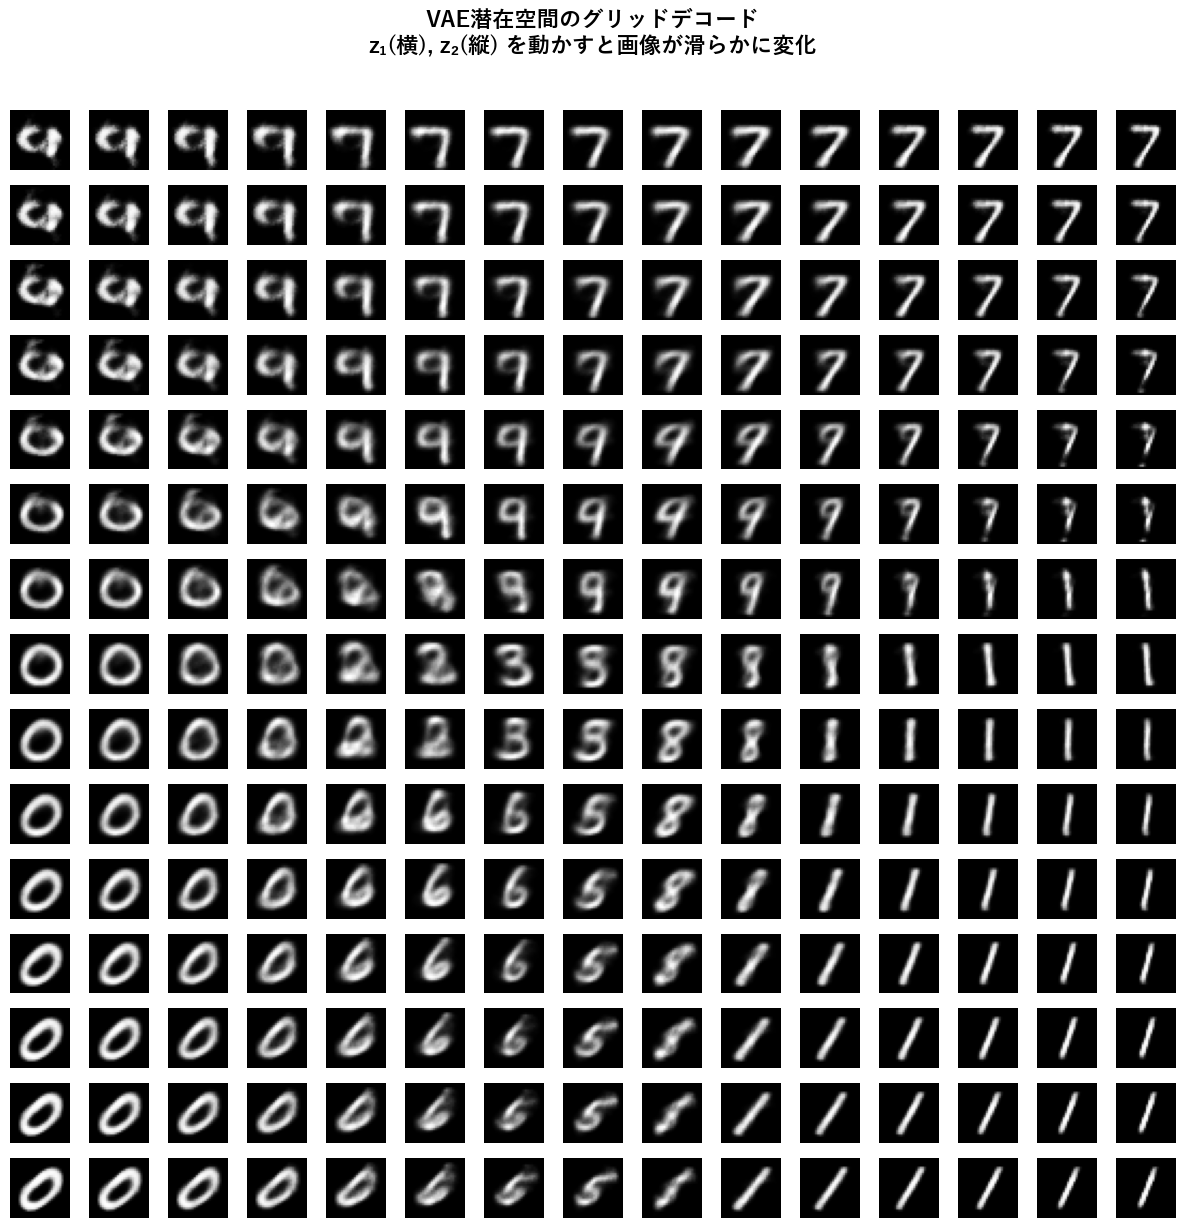

💡 観察ポイント:
   - 隣り合う画像が滑らかに変化している → 潜在空間が「連続的」な証拠
   - z₁方向とz₂方向で違う属性が変化している可能性がある
   - これが画像変容（Morphing）の基本原理です！


In [11]:
# ============================================================
# VAE潜在空間のグリッドデコード
# 潜在空間の各点から画像を生成して並べる
# ============================================================

model_vae.eval()

# 潜在空間のグリッドを作成
n_grid = 15
z1_range = np.linspace(-3, 3, n_grid)
z2_range = np.linspace(-3, 3, n_grid)

# 各格子点からデコード
fig, axes = plt.subplots(n_grid, n_grid, figsize=(12, 12))

with torch.no_grad():
    for i, z2 in enumerate(reversed(z2_range)):
        for j, z1 in enumerate(z1_range):
            z = torch.tensor([[z1, z2]], dtype=torch.float32).to(device)
            img = model_vae.decode(z).cpu().numpy().reshape(28, 28)
            axes[i, j].imshow(img, cmap='gray')
            axes[i, j].axis('off')

# 軸ラベル
fig.suptitle('VAE潜在空間のグリッドデコード\nz₁(横), z₂(縦) を動かすと画像が滑らかに変化',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('fig_300_05_vae_grid_decode.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 観察ポイント:")
print("   - 隣り合う画像が滑らかに変化している → 潜在空間が「連続的」な証拠")
print("   - z₁方向とz₂方向で違う属性が変化している可能性がある")
print("   - これが画像変容（Morphing）の基本原理です！")

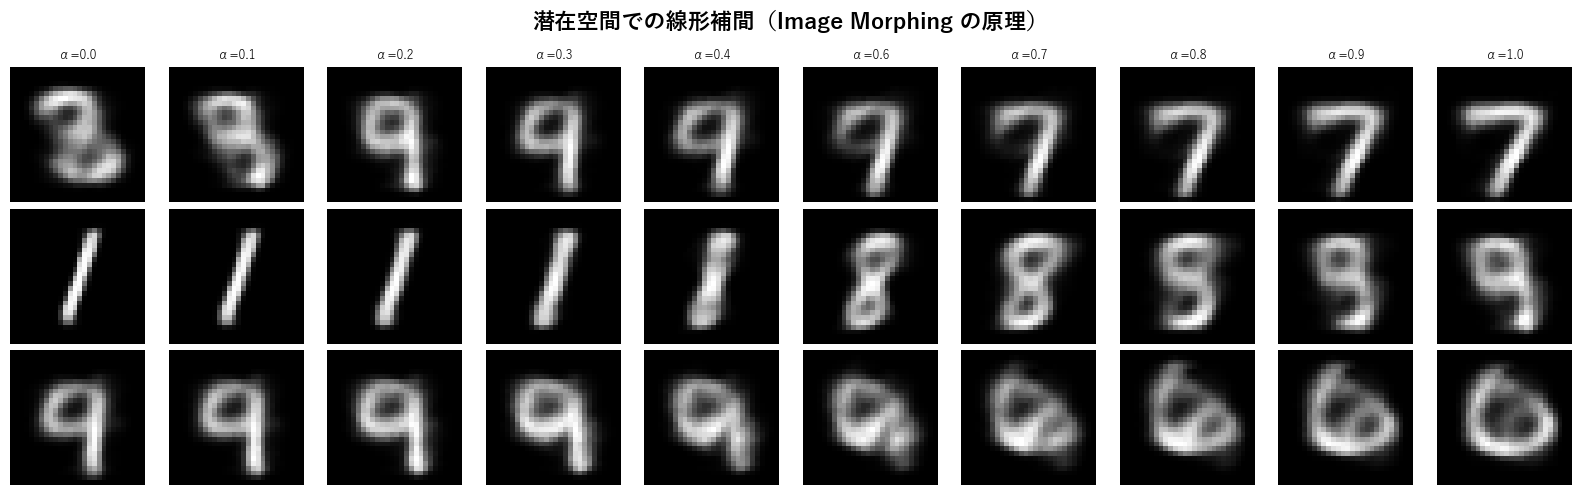

💡 これがImage Morphingの基本原理です！
   1. 画像Aをエンコード → z_A
   2. 画像Bをエンコード → z_B
   3. z_A から z_B へ少しずつ移動
   4. 各中間点をデコード → 滑らかな変容


In [12]:
# ============================================================
# 2つの数字間の補間（潜在空間で直線移動）
# ============================================================

model_vae.eval()

# テストデータから異なる数字のペアを取得
def get_digit_sample(dataset, digit, idx=0):
    """指定した数字のサンプルを取得"""
    count = 0
    for img, label in dataset:
        if label == digit:
            if count == idx:
                return img
            count += 1
    return None

# 3→7 と 1→9 の補間を行う
pairs = [(3, 7), (1, 9), (4, 6)]
n_steps = 10

fig, axes = plt.subplots(len(pairs), n_steps, figsize=(16, 5))

with torch.no_grad():
    for row, (d1, d2) in enumerate(pairs):
        # 2つの数字のサンプルを取得
        img1 = get_digit_sample(test_dataset, d1).view(1, -1).to(device)
        img2 = get_digit_sample(test_dataset, d2).view(1, -1).to(device)

        # 潜在空間にエンコード
        mu1, _ = model_vae.encode(img1)
        mu2, _ = model_vae.encode(img2)

        # 潜在空間で線形補間
        for i, alpha in enumerate(np.linspace(0, 1, n_steps)):
            z_interp = (1 - alpha) * mu1 + alpha * mu2
            img_interp = model_vae.decode(z_interp).cpu().numpy().reshape(28, 28)
            axes[row, i].imshow(img_interp, cmap='gray')
            axes[row, i].axis('off')
            if row == 0:
                axes[row, i].set_title(f'α={alpha:.1f}', fontsize=9)

        # 行ラベル
        axes[row, 0].set_ylabel(f'{d1}→{d2}', fontsize=14, rotation=0, labelpad=30)

fig.suptitle('潜在空間での線形補間（Image Morphing の原理）',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_300_06_latent_interpolation.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 これがImage Morphingの基本原理です！")
print("   1. 画像Aをエンコード → z_A")
print("   2. 画像Bをエンコード → z_B")
print("   3. z_A から z_B へ少しずつ移動")
print("   4. 各中間点をデコード → 滑らかな変容")

---

## まとめ

### 🎯 このノートブックで学んだこと

**潜在空間の基本概念**
- ✓ 潜在空間とは、データの背後にある「本質的な要因」が住む低次元の空間
- ✓ マニフォールド仮説：自然なデータは高次元空間の低次元部分多様体上に集中している

**AE vs VAEの潜在空間**
- ✓ AEの潜在空間は不規則で隙間がある → 補間や生成に向かない
- ✓ VAEはKL正則化により連続的で均一な潜在空間を持つ → 生成・補間が可能

**潜在コードの操作**
- ✓ 潜在空間での線形補間により、画像が滑らかに変化する
- ✓ これが画像変容（Image Morphing）の基本原理

### 📊 潜在空間のチートシート

| 観点 | 内容 |
|------|------|
| 潜在空間とは | データの本質的な構造を捉えた低次元空間 |
| なぜ可能か | マニフォールド仮説（データは低次元に集中） |
| AEの特徴 | 再構成のみ最適化、不規則な空間 |
| VAEの特徴 | KL正則化で連続・均一、生成に適する |
| 画像変容の原理 | 潜在コード間を補間→デコード |

### ⚠️ よくある間違い

❌ 「潜在空間はPCAと同じ」
✅ PCAは線形変換のみ。AE/VAEの潜在空間はニューラルネットワークによる非線形変換で、より複雑な構造を捉えられる

❌ 「潜在次元は小さいほど良い」
✅ 小さすぎると情報が失われる。データの複雑さに応じて適切な次元を選ぶ必要がある

❌ 「AEの潜在空間でも補間できる」
✅ できるが品質が低い。隙間の点をデコードすると崩れた画像になりやすい。VAEの正則化が重要

### ✅ 学習チェックリスト

- [ ] 「潜在空間」を自分の言葉で説明できるか？
- [ ] マニフォールド仮説の意味を理解しているか？
- [ ] AEとVAEの潜在空間の違いを3つ以上挙げられるか？
- [ ] 潜在空間での補間がなぜ滑らかな画像変化を生むか説明できるか？

---

### 📚 練習問題

1. **潜在次元の変更**: 潜在次元を2から10に変更してAEを再学習し、再構成品質がどう変わるか確認してみましょう
2. **別のデータセット**: Fashion-MNISTでVAEを学習し、衣服カテゴリがどのように潜在空間に配置されるか観察してみましょう
3. **補間の探索**: お気に入りの数字ペアを選び、潜在空間での補間を試してみましょう

---

**次のステップ**: ノートブック301「VAE潜在空間の探索」で、潜在空間のクラスタ構造をt-SNE/PCAで詳しく分析し、デコーダで画像を復元する実験を深掘りします！

---

## 🎓 自己評価クイズ

学習内容を確認しましょう！すぐに答えを見ずに、まず自分で考えてみてください。

### Q1: 784次元のMNIST画像を2次元に圧縮しても数字を区別できるのはなぜ？

<details>
<summary>💡 答えを見る</summary>

**答え**: マニフォールド仮説により、手書き数字は784次元空間の中の低次元の多様体上に集中しているため

784個のピクセルは独立ではなく、「数字の種類」「太さ」「傾き」など少数の潜在的な要因で決まります。これらの要因は2次元でも十分に区別可能なことが多いのです。

</details>

---

### Q2: VAEの潜在空間がAEよりも補間に適している理由は？

<details>
<summary>💡 答えを見る</summary>

**答え**: VAEはKLダイバージェンス正則化によって、潜在空間が標準正規分布N(0,I)に近くなるよう学習するため

この正則化により、潜在空間が「連続的」かつ「隙間のない」構造になります。AEには隙間があるため、補間の途中で意味のない画像が生成されやすいのです。

</details>

---

### Q3: 潜在空間での「線形補間」とはどういう操作か？

<details>
<summary>💡 答えを見る</summary>

**答え**: 2つの潜在コード z₁ と z₂ の間を、z = (1-α)·z₁ + α·z₂ (α: 0→1) で移動する操作

α=0 のとき z₁（画像A）、α=1 のとき z₂（画像B）になり、中間の α では両方の特徴が混ざった画像が生成されます。これが Image Morphing の基本です。

</details>

---

### Q4: 潜在次元を1にしたら何が起きるか予想してください

<details>
<summary>💡 答えを見る</summary>

**答え**: 情報が大幅に失われ、再構成品質が大きく低下する

10種類の数字を1次元の直線上に配置しなければならないため、数字間の区別が困難になります。2次元なら平面上に配置できるため、より多くの情報を保持できます。ただし、類似した数字（例: 3と8）は1次元でも近くに配置されるーこの「類似性の保存」が潜在空間の本質です。

</details>